Ce codelab s'appuie largement sur un [exemple de code de scikit-learn](https://scikit-learn.org/stable/auto_examples/neighbors/plot_lof_outlier_detection.html#sphx-glr-auto-examples-neighbors-plot-lof-outlier-detection-py).

In [1]:
%matplotlib inline


===========================================================
Détection d'outliers avec le Local Outlier Factor (LOF)
===========================================================

L'algorithme Local Outlier Factor (LOF) est une méthode non supervisée de
détection d'anomalies qui calcule l'écart de densité locale d'un point par
rapport à ses voisins. Il considère comme outliers les exemples dont la densité
est nettement plus faible que celle de leurs voisins. Cet exemple montre
comment utiliser le LOF pour la détection d'outliers, l'usage par défaut de cet
estimateur dans scikit-learn. Utilisé pour la détection d'outliers, le LOF n'a
pas de méthodes predict, decision_function ni score_samples. Voir le
`guide utilisateur <outlier_detection>` : pour la différence entre détection
d'outliers et détection de nouveautés, et pour utiliser le LOF en détection de
nouveautés.

Le nombre de voisins considérés (paramètre n_neighbors) est généralement choisi
1) plus grand que le nombre minimal d'exemples qu'un cluster doit contenir, pour
que d'autres exemples puissent être des outliers locaux par rapport à ce
cluster, et 2) plus petit que le nombre maximal d'exemples proches qui peuvent
potentiellement être des outliers locaux.
En pratique, ces informations ne sont généralement pas disponibles, et
n_neighbors=20 fonctionne bien en général.

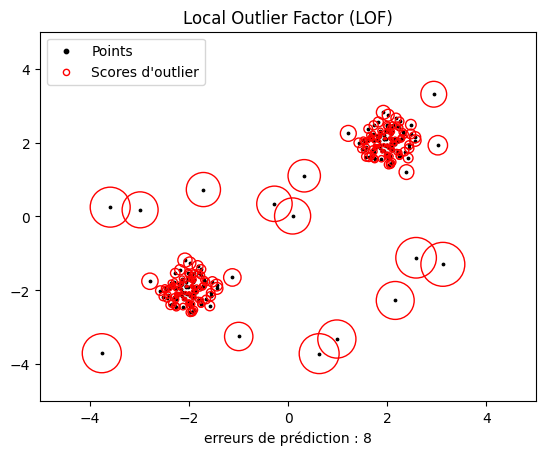

In [2]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import LocalOutlierFactor

np.random.seed(42)

# Génération des données d'entraînement
X_inliers = 0.3 * np.random.randn(100, 2)
X_inliers = np.r_[X_inliers + 2, X_inliers - 2]

# Génération de quelques outliers
X_outliers = np.random.uniform(low=-4, high=4, size=(20, 2))
X = np.r_[X_inliers, X_outliers]

n_outliers = len(X_outliers)
ground_truth = np.ones(len(X), dtype=int)
ground_truth[-n_outliers:] = -1

# Entraînement du modèle pour la détection d'outliers (usage par défaut)
clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1)
# fit_predict calcule les labels prédits des exemples d'entraînement
# (utilisé pour la détection d'outliers, l'estimateur n'a pas de méthodes
# predict, decision_function ni score_samples).
y_pred = clf.fit_predict(X)
n_errors = (y_pred != ground_truth).sum()
X_scores = clf.negative_outlier_factor_

plt.title("Local Outlier Factor (LOF)")
plt.scatter(X[:, 0], X[:, 1], color="k", s=3.0, label="Points")
# Cercles de rayon proportionnel au score d'outlier
radius = (X_scores.max() - X_scores) / (X_scores.max() - X_scores.min())
plt.scatter(
  X[:, 0],
  X[:, 1],
  s=1000 * radius,
  edgecolors="r",
  facecolors="none",
  label="Scores d'outlier",
)
plt.axis("tight")
plt.xlim((-5, 5))
plt.ylim((-5, 5))
plt.xlabel("erreurs de prédiction : %d" % (n_errors))
legend = plt.legend(loc="upper left")
legend.legend_handles[0]._sizes = [10]
legend.legend_handles[1]._sizes = [20]
plt.show()